# Import Libraries

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

# Load the Dataset

In [2]:
df=pd.read_csv('loan_approval_data.csv')
df.head()

,Applicant_ID,Applicant_Income,Coapplicant_Income,Employment_Status,Age,Marital_Status,Dependents,Credit_Score,Existing_Loans,DTI_Ratio,Savings,Collateral_Value,Loan_Amount,Loan_Term,Loan_Purpose,Property_Area,Education_Level,Gender,Employer_Category,Loan_Approved
0,1.0,17795.0,1387.0,Salaried,51.0,Married,0.0,637.0,4.0,0.53,19403.0,45638.0,16619.0,84.0,Personal,Urban,Not Graduate,Female,Private,No
1,2.0,2860.0,2679.0,Salaried,46.0,Married,3.0,621.0,2.0,0.30,2580.0,49272.0,38687.0,NaN,Car,Semiurban,Graduate,NaN,Private,No
2,3.0,7390.0,2106.0,Salaried,25.0,Single,2.0,674.0,4.0,0.20,13844.0,6908.0,27943.0,72.0,NaN,Urban,NaN,Female,Government,Yes
3,4.0,13964.0,8173.0,Salaried,40.0,Married,2.0,579.0,3.0,0.31,9553.0,10844.0,27819.0,60.0,Business,Rural,Graduate,Female,Government,No
4,5.0,13284.0,4223.0,Self-employed,31.0,Single,2.0,721.0,1.0,0.29,9386.0,37629.0,12741.0,72.0,Car,NaN,Graduate,Male,Private,Yes


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 20 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Applicant_ID        950 non-null    float64
 1   Applicant_Income    950 non-null    float64
 2   Coapplicant_Income  950 non-null    float64
 3   Employment_Status   950 non-null    object 
 4   Age                 950 non-null    float64
 5   Marital_Status      950 non-null    object 
 6   Dependents          950 non-null    float64
 7   Credit_Score        950 non-null    float64
 8   Existing_Loans      950 non-null    float64
 9   DTI_Ratio           950 non-null    float64
 10  Savings             950 non-null    float64
 11  Collateral_Value    950 non-null    float64
 12  Loan_Amount         950 non-null    float64
 13  Loan_Term           950 non-null    float64
 14  Loan_Purpose        950 non-null    object 
 15  Property_Area       950 non-null    object 
 16  Educati

In [4]:
df.describe()

,Applicant_ID,Applicant_Income,Coapplicant_Income,Age,Dependents,Credit_Score,Existing_Loans,DTI_Ratio,Savings,Collateral_Value,Loan_Amount,Loan_Term
count,950.000000,950.000000,950.000000,950.000000,950.000000,950.000000,950.000000,950.000000,950.000000,950.000000,950.000000,950.000000
mean,501.220000,10852.571579,5082.455789,39.971579,1.474737,676.033684,1.950526,0.347263,9940.452632,24802.792632,20522.825263,48.000000
std,289.608451,5061.632859,2943.161570,11.139797,1.105067,71.346015,1.406246,0.144341,5860.736885,14345.696031,11504.142575,24.245322
min,1.000000,2009.000000,1.000000,21.000000,0.000000,550.000000,0.000000,0.100000,65.000000,36.000000,1015.000000,12.000000
25%,250.250000,6730.750000,2472.750000,30.250000,1.000000,616.250000,1.000000,0.220000,4760.250000,12698.250000,9806.250000,24.000000
50%,499.500000,10548.000000,5205.500000,40.000000,1.000000,678.000000,2.000000,0.340000,9880.500000,24321.000000,21210.500000,48.000000
75%,752.750000,15190.000000,7620.750000,49.000000,2.000000,737.000000,3.000000,0.480000,15074.500000,36947.000000,30263.000000,72.000000
max,1000.000000,19988.000000,9996.000000,59.000000,3.000000,799.000000,4.000000,0.600000,19996.000000,49954.000000,39995.000000,84.000000


In [5]:
df.isnull().sum()

Applicant_ID          50
Applicant_Income      50
Coapplicant_Income    50
Employment_Status     50
Age                   50
Marital_Status        50
Dependents            50
Credit_Score          50
Existing_Loans        50
DTI_Ratio             50
Savings               50
Collateral_Value      50
Loan_Amount           50
Loan_Term             50
Loan_Purpose          50
Property_Area         50
Education_Level       50
Gender                50
Employer_Category     50
Loan_Approved         50
dtype: int64

In [6]:
df.shape

(1000, 20)

In [7]:
df.columns

Index(['Applicant_ID', 'Applicant_Income', 'Coapplicant_Income',
       'Employment_Status', 'Age', 'Marital_Status', 'Dependents',
       'Credit_Score', 'Existing_Loans', 'DTI_Ratio', 'Savings',
       'Collateral_Value', 'Loan_Amount', 'Loan_Term', 'Loan_Purpose',
       'Property_Area', 'Education_Level', 'Gender', 'Employer_Category',
       'Loan_Approved'],
      dtype='object')

In [8]:
df['Loan_Approved'].value_counts()

Loan_Approved
No     652
Yes    298
Name: count, dtype: int64

# Data Cleaning

# #1 Handle Missing Values

In [9]:
categorical_cols=df.select_dtypes(include=['object']).columns
numerical_cols=df.select_dtypes(include=['number']).columns

In [10]:
from sklearn.impute import SimpleImputer

num_imp=SimpleImputer(strategy='mean')
df[numerical_cols] = num_imp.fit_transform(df[numerical_cols])

In [11]:
catg_imp=SimpleImputer(strategy='most_frequent')
df[categorical_cols] = catg_imp.fit_transform(df[categorical_cols])

In [12]:
df.isnull().sum()

Applicant_ID          0
Applicant_Income      0
Coapplicant_Income    0
Employment_Status     0
Age                   0
Marital_Status        0
Dependents            0
Credit_Score          0
Existing_Loans        0
DTI_Ratio             0
Savings               0
Collateral_Value      0
Loan_Amount           0
Loan_Term             0
Loan_Purpose          0
Property_Area         0
Education_Level       0
Gender                0
Employer_Category     0
Loan_Approved         0
dtype: int64

# EDA - Exploratory Data Analysis

In [13]:
df=df.drop(columns=['Applicant_ID'])

Text(0.5, 1.0, 'Is Loan approved or not')

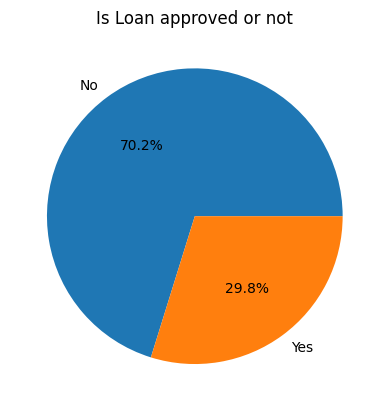

In [14]:
# how balanced our classes are?

classes_count = df['Loan_Approved'].value_counts()
plt.pie(classes_count,labels=['No','Yes'],autopct='%1.1f%%')
plt.title('Is Loan approved or not')

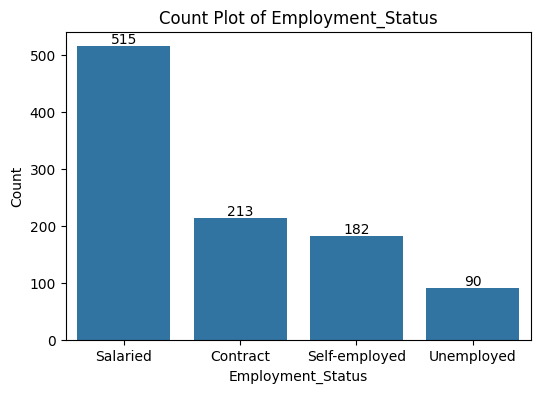

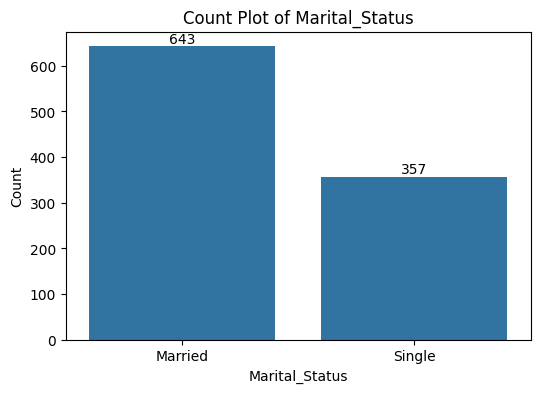

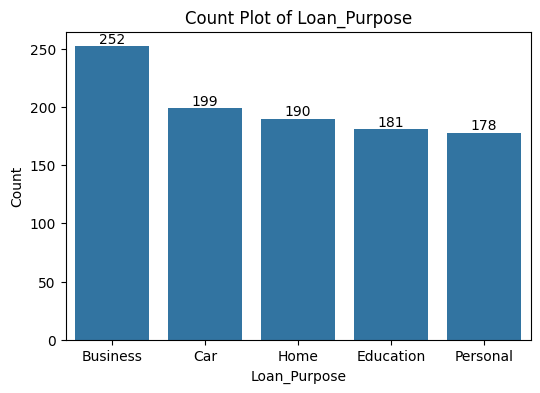

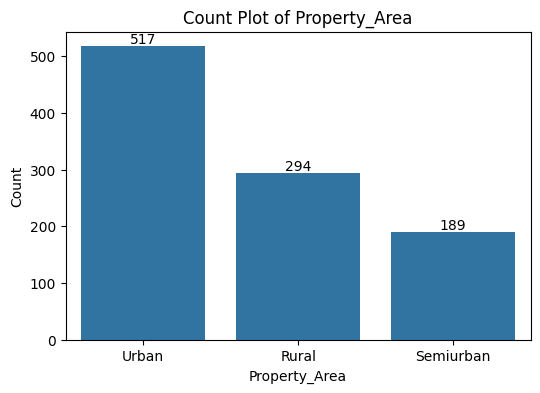

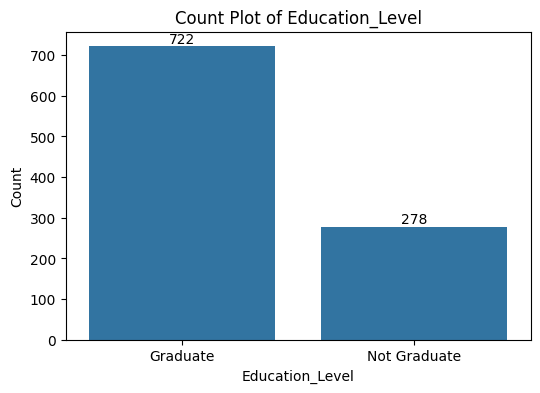

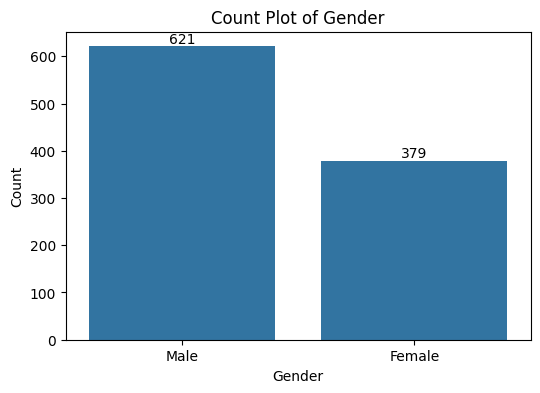

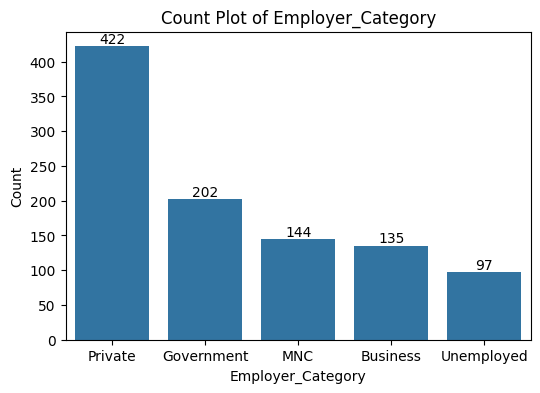

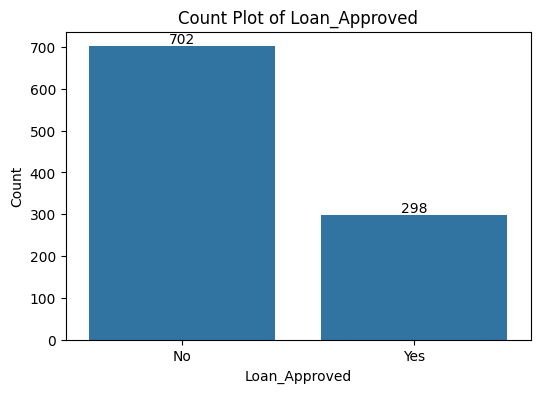

In [15]:
# Create barplot for all categorical cols

cols=['Employment_Status','Marital_Status','Loan_Purpose','Property_Area','Employer_Category']
for col in categorical_cols:
    
    count_data = df[col].value_counts()
    plt.figure(figsize=(6,4))
    
    ax = sns.barplot(
        x=count_data.index,
        y=count_data.values)
    
    ax.bar_label(ax.containers[0])
    
    plt.title(f'Count Plot of {col}')
    plt.xlabel(col)
    plt.ylabel('Count')
    
    plt.show()

Text(0.5, 1.0, 'Applicant Income Distribution')

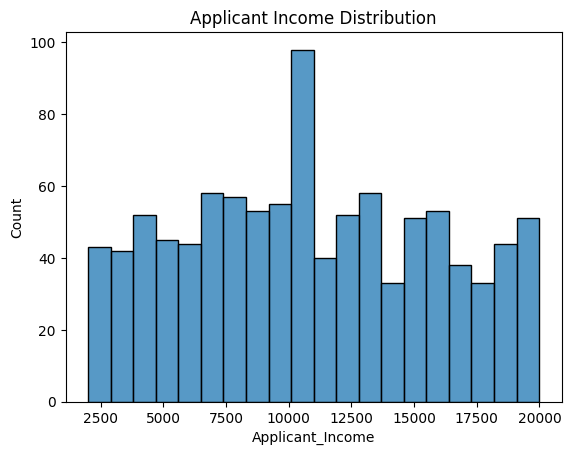

In [16]:
# Analyze Applicant Income using Histogram

sns.histplot(data=df,x='Applicant_Income',bins=20)
plt.title('Applicant Income Distribution')

Text(0.5, 1.0, 'Coapplicant Income Distribution')

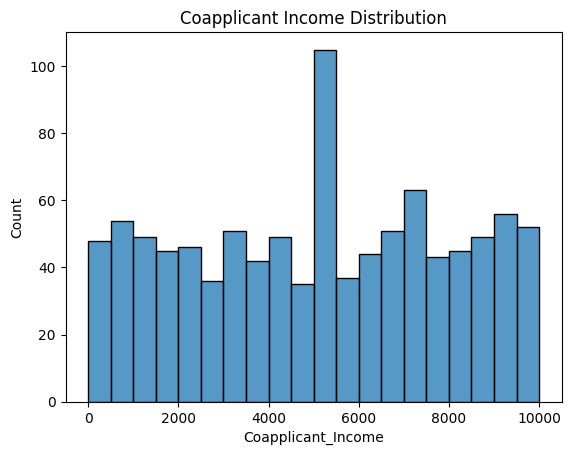

In [17]:
# Analyze Coapplicant Income using Histogram

sns.histplot(data=df,x='Coapplicant_Income',bins=20)
plt.title('Coapplicant Income Distribution')

Text(0.5, 1.0, 'Distribution of Credit Scores by Loan Approval Status')

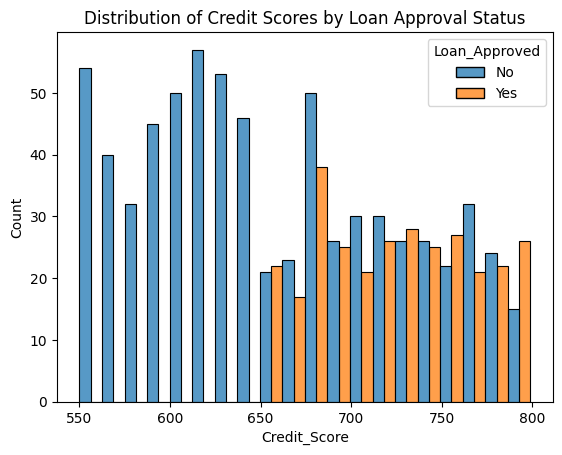

In [18]:
# Credit Score with Loan Approval Status

sns.histplot(data=df,x='Credit_Score',hue='Loan_Approved',bins=20,multiple='dodge')
plt.title("Distribution of Credit Scores by Loan Approval Status")

Text(0.5, 1.0, 'Distribution of Applicant Income by Loan Approval Status')

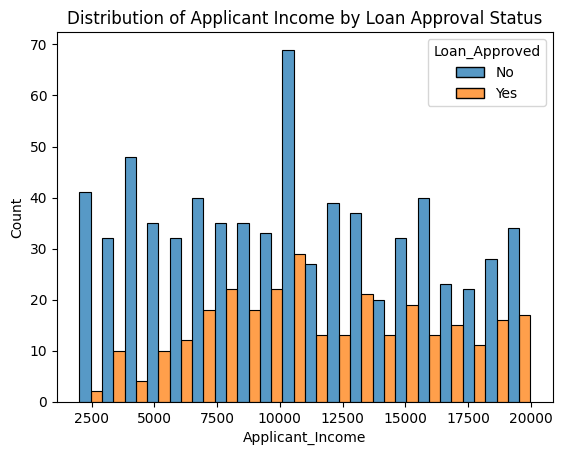

In [19]:
# Applicant Income with Loan Approval Status

sns.histplot(data=df,x='Applicant_Income',hue='Loan_Approved',bins=20,multiple='dodge')
plt.title("Distribution of Applicant Income by Loan Approval Status")

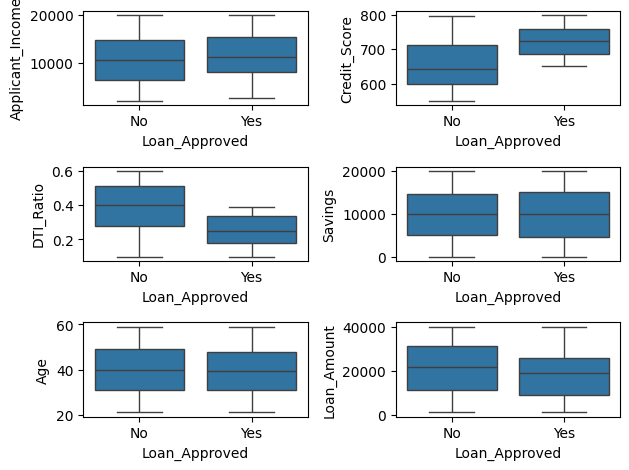

In [20]:
# Outlier detection using Boxplot

fig,axes = plt.subplots(3,2)

sns.boxplot(ax=axes[0,0],data=df,x='Loan_Approved',y='Applicant_Income')
sns.boxplot(ax=axes[0,1],data=df,x='Loan_Approved',y='Credit_Score')
sns.boxplot(ax=axes[1,0],data=df,x='Loan_Approved',y='DTI_Ratio')
sns.boxplot(ax=axes[1,1],data=df,x='Loan_Approved',y='Savings')
sns.boxplot(ax=axes[2,0],data=df,x='Loan_Approved',y='Age')
sns.boxplot(ax=axes[2,1],data=df,x='Loan_Approved',y='Loan_Amount')

plt.tight_layout()

# Feature Encoding

In [21]:
from sklearn.preprocessing import LabelEncoder, OneHotEncoder

le=LabelEncoder()
df['Education_Level']=le.fit_transform(df['Education_Level'])
df['Loan_Approved']=le.fit_transform(df['Loan_Approved'])
df['Gender']=le.fit_transform(df['Gender'])

In [22]:
cols=['Employment_Status','Marital_Status','Loan_Purpose','Property_Area','Employer_Category']

ohe=OneHotEncoder(drop='first',sparse_output=False,handle_unknown='ignore')

encoded = ohe.fit_transform(df[cols])

encoded_df=pd.DataFrame(encoded,columns=ohe.get_feature_names_out(cols),index=df.index)

df = pd.concat([df,encoded_df],axis=1)

In [23]:
df=df.drop(columns=cols)

In [24]:
df.head()

,Applicant_Income,Coapplicant_Income,Age,Dependents,Credit_Score,Existing_Loans,DTI_Ratio,Savings,Collateral_Value,Loan_Amount,...,Loan_Purpose_Car,Loan_Purpose_Education,Loan_Purpose_Home,Loan_Purpose_Personal,Property_Area_Semiurban,Property_Area_Urban,Employer_Category_Government,Employer_Category_MNC,Employer_Category_Private,Employer_Category_Unemployed
0,17795.0,1387.0,51.0,0.0,637.0,4.0,0.53,19403.0,45638.0,16619.0,...,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0
1,2860.0,2679.0,46.0,3.0,621.0,2.0,0.30,2580.0,49272.0,38687.0,...,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0
2,7390.0,2106.0,25.0,2.0,674.0,4.0,0.20,13844.0,6908.0,27943.0,...,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0
3,13964.0,8173.0,40.0,2.0,579.0,3.0,0.31,9553.0,10844.0,27819.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
4,13284.0,4223.0,31.0,2.0,721.0,1.0,0.29,9386.0,37629.0,12741.0,...,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0


# Correlation Heatmap

<Axes: >

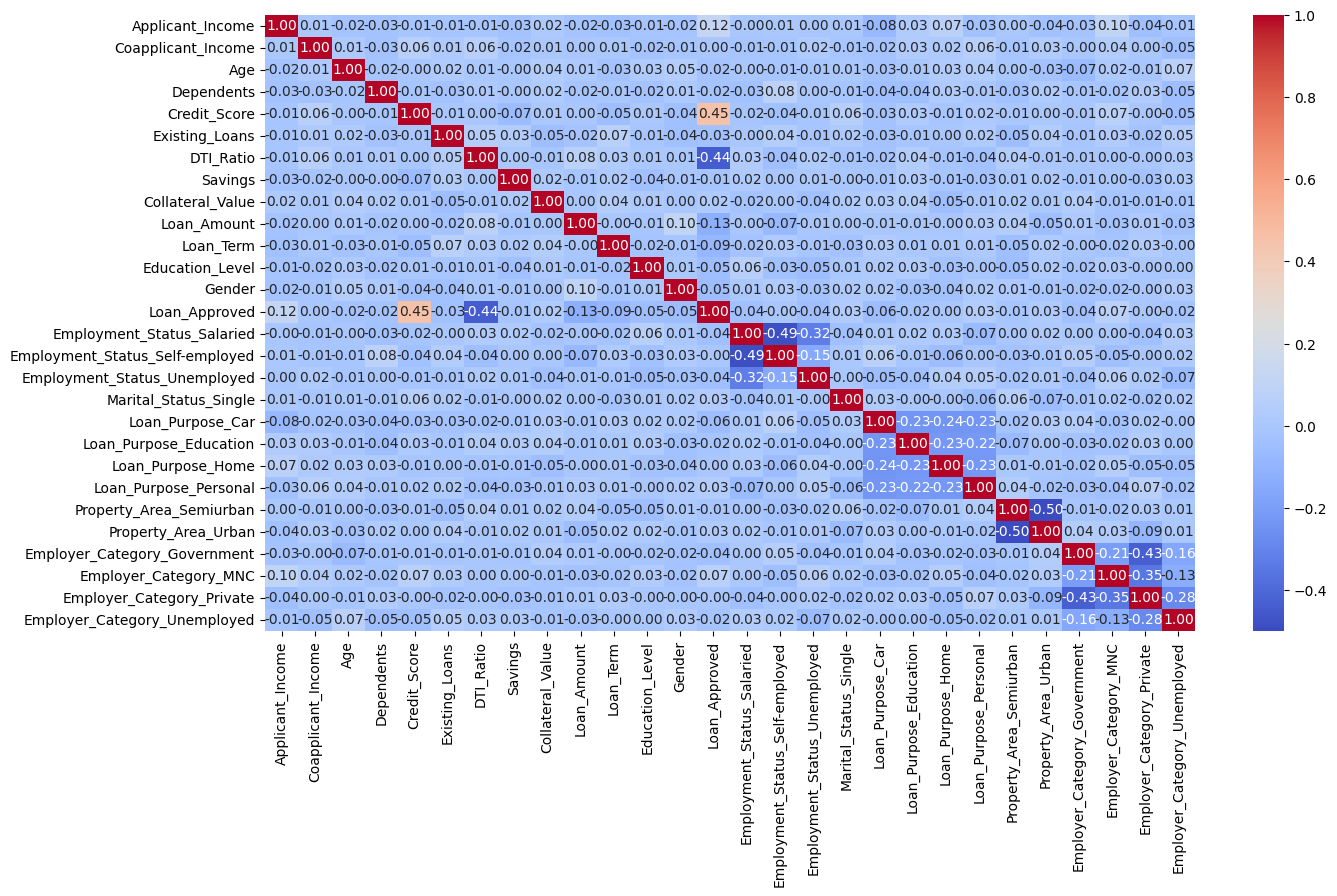

In [25]:
num_cols=df.select_dtypes(include='number')
corr_matrix=num_cols.corr()

plt.figure(figsize=(15,8))
sns.heatmap(corr_matrix,annot=True,fmt='.2f',cmap='coolwarm')

In [26]:
num_cols.corr()['Loan_Approved'].sort_values(ascending=False)

Loan_Approved                      1.000000
Credit_Score                       0.451175
Applicant_Income                   0.119796
Employer_Category_MNC              0.069049
Loan_Purpose_Personal              0.034043
Marital_Status_Single              0.030182
Property_Area_Urban                0.025963
Collateral_Value                   0.021868
Coapplicant_Income                 0.004230
Loan_Purpose_Home                  0.002118
Employment_Status_Self-employed   -0.001337
Employer_Category_Private         -0.003347
Property_Area_Semiurban           -0.012967
Savings                           -0.013437
Loan_Purpose_Education            -0.016684
Employer_Category_Unemployed      -0.021468
Age                               -0.022343
Dependents                        -0.023811
Existing_Loans                    -0.034794
Employer_Category_Government      -0.039187
Employment_Status_Salaried        -0.041428
Employment_Status_Unemployed      -0.044464
Education_Level                 

# Train-Test-Split + Feature Scaling

In [27]:
x = df.drop(columns=['Loan_Approved'])
y = df['Loan_Approved']

In [28]:
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.2,random_state=42)

In [29]:
from sklearn.preprocessing import StandardScaler

ss = StandardScaler()

x_train_ss = ss.fit_transform(x_train)
x_test_ss = ss.transform(x_test)

# Train & Evaluate Models

In [30]:
#1 Logistic Regression

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, recall_score, f1_score
log = LogisticRegression()
log.fit(x_train_ss,y_train)

y_pred_l=log.predict(x_test_ss)

print('Precision:', precision_score(y_test,y_pred_l))
print('Recall:', recall_score(y_test,y_pred_l))
print('F1 score:', f1_score(y_test,y_pred_l))
print('Accuracy:', accuracy_score(y_test,y_pred_l))
print('CM:', confusion_matrix(y_test,y_pred_l))

Precision: 0.7833333333333333
Recall: 0.7704918032786885
F1 score: 0.7768595041322314
Accuracy: 0.865
CM: [[126  13]
 [ 14  47]]


In [31]:
#2 KNN

from sklearn.neighbors import KNeighborsClassifier

knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(x_train_ss,y_train)

y_pred_k=knn.predict(x_test_ss)

print('Precision:', precision_score(y_test,y_pred_k))
print('Recall:', recall_score(y_test,y_pred_k))
print('F1 score:', f1_score(y_test,y_pred_k))
print('Accuracy:', accuracy_score(y_test,y_pred_k))
print('CM:', confusion_matrix(y_test,y_pred_k))

Precision: 0.6274509803921569
Recall: 0.5245901639344263
F1 score: 0.5714285714285714
Accuracy: 0.76
CM: [[120  19]
 [ 29  32]]


In [32]:
#3 Naive Bayes

from sklearn.naive_bayes import GaussianNB

gnb = GaussianNB()
gnb.fit(x_train_ss,y_train)

y_pred_n=gnb.predict(x_test_ss)

print('Precision:', precision_score(y_test,y_pred_n))
print('Recall:', recall_score(y_test,y_pred_n))
print('F1 score:', f1_score(y_test,y_pred_n))
print('Accuracy:', accuracy_score(y_test,y_pred_n))
print('CM:', confusion_matrix(y_test,y_pred_n))

Precision: 0.8035714285714286
Recall: 0.7377049180327869
F1 score: 0.7692307692307693
Accuracy: 0.865
CM: [[128  11]
 [ 16  45]]
